In [9]:
from mp_api.client import MPRester
API_KEY = "4IeHY5jVcrgiKXNuAo6Jgs7yC0Z3hsli"
try:


    with MPRester(API_KEY) as mpr:
        # Query for Li-based cathode materials with high energy density
        materials = mpr.materials.insertion_electrodes.search(
            working_ion="Li",
            average_voltage = (0, 99999999),
            fields=[
                "battery_id", "formula_discharge", "average_voltage"
                , "energy_grav", "energy_vol", "capacity_grav", "capacity_vol", "stability_charge", "fracA_charge", "stability_charge", "max_delta_volume", "stability_discharge", "fracA_discharge"
            ]
        )

        # Convert to pandas for research analysis
        import pandas as pd
        df = pd.DataFrame([doc.dict() for doc in docs])
        print(df)

except Exception as e:
    print(f"An error occurred: {e}")


Retrieving InsertionElectrodeDoc documents: 100%|██████████| 2702/2702 [00:00<00:00, 4106.58it/s]

         battery_id formula_discharge  max_delta_volume  average_voltage  \
0          mp-28_Li             Li3Ce          2.951183        -0.444846   
1        mp-2074_Li             Li3Sb          1.569237         1.015953   
2      mp-568806_Li              LiC6          0.025414         0.084405   
3      mp-573471_Li           Li22Sn5          0.009450        -0.362516   
4       mp-22902_Li              LiBi          0.368255         0.796796   
...             ...               ...               ...              ...   
2769   mp-801332_Li    Li3VCrP2(HO5)2          0.076598        -0.048828   
2770   mp-806951_Li     LiVFeP2(O4F)2          0.017783         0.617592   
2771   mp-802114_Li     LiMnVP2(HO5)2          0.045934        -2.235023   
2772   mp-801251_Li     LiVCrP2(O4F)2          0.017284        -1.876176   
2773  mp-1227445_Li   BaSrLiNdTlCu2O7          0.071513         0.911354   

      capacity_grav  capacity_vol  energy_grav   energy_vol  fracA_charge  \
0        4

Higher average voltage → higher pack energy

Higher capacity → longer range

Lower formation energy → stability & safety

Smaller volume change → longer cycle life

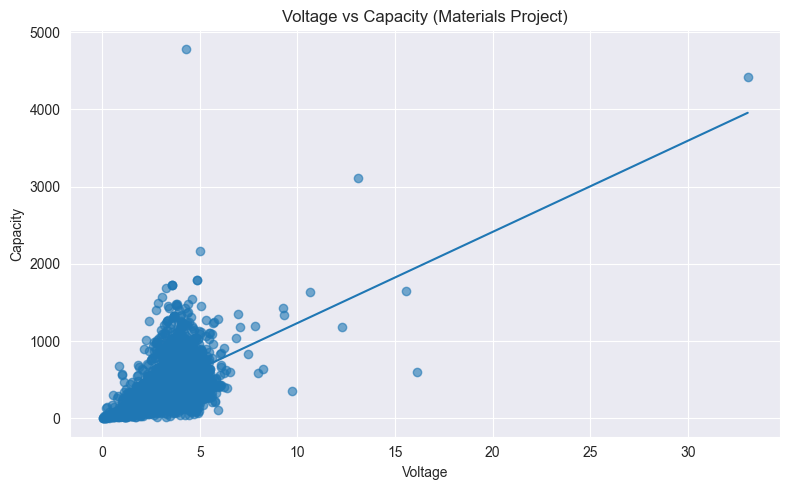

Slope: 118.00647261384869
Intercept: 53.60433248381645
R²: 0.25816817400807

         battery_id  average_voltage  capacity_grav
1731   mp-759383_Li         5.932807     108.241697
375    mp-773010_Li         4.901250      72.842359
2145   mp-884044_Li         4.960861      92.247804
2578   mp-775293_Li         4.703034      54.947593
2208   mp-532590_Li         4.780452      82.768530
2211   mp-543110_Li         4.874744     114.649959
2444   mp-766215_Li         4.730191      92.539731
737     mp-26368_Li         5.161204     170.690215
721     mp-26319_Li         5.778521     206.900345
98       mp-3731_Li         4.955459     149.721118
996    mp-504371_Li         4.829746     134.851441
633     mp-26049_Li         5.642345     213.458316
724     mp-26329_Li         5.791190     220.286124
1689   mp-758792_Li         4.528868      83.947070
1571   mp-757434_Li         4.423369      47.953190
287    mp-757896_Li         4.526761      91.241524
2680   mp-769544_Li         4.778282   

In [21]:
from mp_api.client import MPRester
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# -------------------------------
# 2. Convert to DataFrame
# -------------------------------
mp_df = pd.DataFrame([{
     "battery_id": m.battery_id,
    "formula_discharge": m.formula_discharge,
    "average_voltage": m.average_voltage,
    "energy_grav": m.energy_grav,
    "capacity_grav": m.energy_grav,
    "stability_charge": m.stability_charge,
    "stability_discharge": m.stability_discharge,
    "max_delta_volume": m.max_delta_volume,
    "fracA_charge": m.fracA_charge,
    "fracA_discharge": m.fracA_discharge
} for m in materials])

# Drop rows with missing values
mp_df = mp_df.dropna()

# -------------------------------
# 3. Define EV-relevant target
# (proxy: density vs stability)
# -------------------------------
X = mp_df[['average_voltage']]
y = mp_df[['capacity_grav']]

# -------------------------------
# 4. Linear regression
# -------------------------------
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
slope = model.coef_[0][0]
intercept = model.intercept_[0]



# -------------------------------
# 5. Plot regression
# -------------------------------
x_line = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
x_line_df = pd.DataFrame(x_line, columns=['average_voltage'])
y_line = model.predict(x_line_df)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6)
plt.plot(x_line, y_line)
plt.xlabel("Voltage")
plt.ylabel("Capacity")
plt.title("Voltage vs Capacity (Materials Project)")
plt.tight_layout()
plt.show()

print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r2)
print()

# -------------------------------
# 6. Rank materials for EV relevance
# -------------------------------
mp_df['ev_score'] = (
    mp_df['average_voltage'].rank(pct=True)
    - mp_df['capacity_grav'].rank(pct=True)
)

mp_df = mp_df.sort_values('ev_score', ascending=False)

# -------------------------------
# 7. Output top materials
# -------------------------------
top_materials = mp_df[['battery_id', 'average_voltage', 'capacity_grav']].head(50)
print(top_materials)


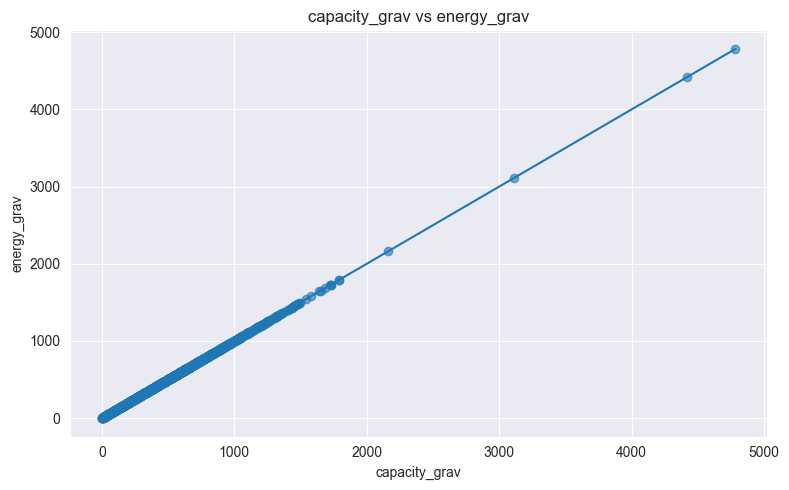

Slope: 0.9999999999999994
Intercept: 2.8421709430404007e-13
R²: 1.0

        battery_id  capacity_grav  energy_grav
0       mp-2074_Li     572.909146   572.909146
1804  mp-760963_Li     327.646929   327.646929
1796  mp-760859_Li     727.368777   727.368777
1797  mp-760888_Li     153.769780   153.769780
1798  mp-760930_Li     364.762985   364.762985
1799  mp-760914_Li     158.383891   158.383891
1800  mp-760934_Li     201.592850   201.592850
1801  mp-760972_Li     139.722589   139.722589
1802  mp-760989_Li     101.097669   101.097669
1803  mp-760983_Li     339.295826   339.295826
1805  mp-761012_Li    1043.096187  1043.096187
1857  mp-764879_Li     532.827020   532.827020
1806  mp-761041_Li     187.336956   187.336956
1807  mp-761082_Li     470.662551   470.662551
1808  mp-761047_Li     341.205316   341.205316
1809  mp-761099_Li     321.522354   321.522354
1810  mp-761101_Li     565.965952   565.965952
1811  mp-761092_Li     595.172762   595.172762
1812  mp-761130_Li     411.558386   41

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# -------------------------------
# 2. Convert to DataFrame
# -------------------------------
mp_df = pd.DataFrame([{
     "battery_id": m.battery_id,
    "formula_discharge": m.formula_discharge,
    "average_voltage": m.average_voltage,
    "energy_grav": m.energy_grav,
    "capacity_grav": m.energy_grav,
    "stability_charge": m.stability_charge,
    "stability_discharge": m.stability_discharge,
    "max_delta_volume": m.max_delta_volume,
    "fracA_charge": m.fracA_charge,
    "fracA_discharge": m.fracA_discharge
} for m in materials])

# Drop rows with missing values
mp_df = mp_df.dropna()

X_param = 'capacity_grav'
Y_param = 'energy_grav'

# -------------------------------
# 3. Define EV-relevant target
# (proxy: density vs stability)
# -------------------------------
X = mp_df[[X_param]]
y = mp_df[[Y_param]]

# -------------------------------
# 4. Linear regression
# -------------------------------
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
slope = model.coef_[0][0]
intercept = model.intercept_[0]


# -------------------------------
# 5. Plot regression
# -------------------------------
x_line = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
x_line_df = pd.DataFrame(x_line, columns=[X_param])
y_line = model.predict(x_line_df)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6)
plt.plot(x_line, y_line)
plt.xlabel(X_param)
plt.ylabel(Y_param)
plt.title(f"{X_param} vs {Y_param}")
plt.tight_layout()
plt.show()

print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r2)
print()

# -------------------------------
# 6. Rank materials for EV relevance
# -------------------------------
mp_df['ev_score'] = (
    mp_df[X_param].rank(pct=True)
    - mp_df[Y_param].rank(pct=True)
)

mp_df = mp_df.sort_values('ev_score', ascending=False)

# -------------------------------
# 7. Output top materials
# -------------------------------
top_materials = mp_df[['battery_id', X_param, Y_param]].head(50)
print(top_materials)


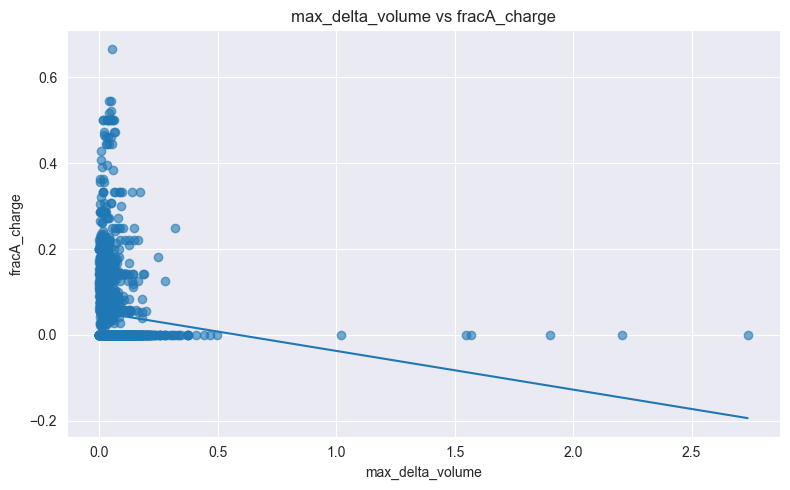

Slope: -0.09020700165806125
Intercept: 0.053050479491814136
R²: 0.011128926058372901

         battery_id  max_delta_volume  fracA_charge
3         mp-124_Li          2.736089           0.0
7      mp-867343_Li          2.204349           0.0
6          mp-80_Li          1.900682           0.0
0        mp-2074_Li          1.569237           0.0
5      mp-623511_Li          1.549197           0.0
390    mp-985585_Li          1.020934           0.0
117    mp-530670_Li          0.495134           0.0
397      mp-9158_Li          0.466413           0.0
394    mp-866194_Li          0.443726           0.0
32    mp-1235941_Li          0.407572           0.0
395    mp-865935_Li          0.375859           0.0
53      mp-19308_Li          0.375394           0.0
50      mp-19279_Li          0.375377           0.0
2       mp-22902_Li          0.368255           0.0
522     mp-19859_Li          0.344482           0.0
431   mp-1111263_Li          0.335830           0.0
357    mp-766486_Li          0

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# -------------------------------
# 2. Convert to DataFrame
# -------------------------------
mp_df = pd.DataFrame([{
     "battery_id": m.battery_id,
    "formula_discharge": m.formula_discharge,
    "average_voltage": m.average_voltage,
    "energy_grav": m.energy_grav,
    "capacity_grav": m.energy_grav,
    "stability_charge": m.stability_charge,
    "stability_discharge": m.stability_discharge,
    "max_delta_volume": m.max_delta_volume,
    "fracA_charge": m.fracA_charge,
    "fracA_discharge": m.fracA_discharge
} for m in materials])

# Drop rows with missing values
mp_df = mp_df.dropna()

X_param = 'max_delta_volume'
Y_param = 'fracA_charge'

# -------------------------------
# 3. Define EV-relevant target
# (proxy: density vs stability)
# -------------------------------
X = mp_df[[X_param]]
y = mp_df[[Y_param]]

# -------------------------------
# 4. Linear regression
# -------------------------------
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
slope = model.coef_[0][0]
intercept = model.intercept_[0]


# -------------------------------
# 5. Plot regression
# -------------------------------
x_line = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
x_line_df = pd.DataFrame(x_line, columns=[X_param])
y_line = model.predict(x_line_df)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6)
plt.plot(x_line, y_line)
plt.xlabel(X_param)
plt.ylabel(Y_param)
plt.title(f"{X_param} vs {Y_param}")
plt.tight_layout()
plt.show()

print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r2)
print()

# -------------------------------
# 6. Rank materials for EV relevance
# -------------------------------
mp_df['ev_score'] = (
    mp_df[X_param].rank(pct=True)
    - mp_df[Y_param].rank(pct=True)
)

mp_df = mp_df.sort_values('ev_score', ascending=False)

# -------------------------------
# 7. Output top materials
# -------------------------------
top_materials = mp_df[['battery_id', X_param, Y_param]].head(50)
print(top_materials)


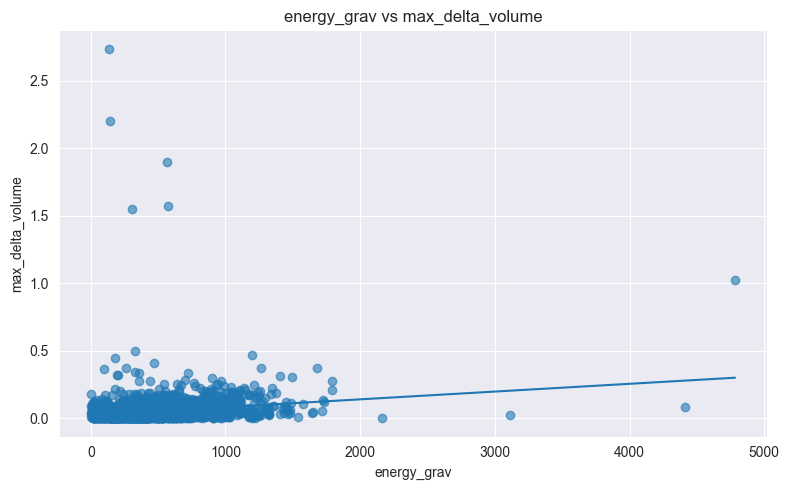

Slope: 5.750662748789399e-05
Intercept: 0.025146476585862654
R²: 0.031903500862383694

         battery_id  energy_grav  max_delta_volume
23    mp-1111688_Li  2161.122703          0.001452
262    mp-756362_Li  1196.401598          0.002416
742     mp-26387_Li   821.900083          0.000098
382    mp-777681_Li  1215.517917          0.005252
1124   mp-752626_Li   906.409899          0.002767
425   mp-1174049_Li   956.211806          0.003642
1394   mp-755069_Li   976.468808          0.004729
1791   mp-760367_Li   911.796514          0.004596
750     mp-26406_Li  1027.137137          0.006549
1531   mp-756863_Li   904.799767          0.005481
167    mp-752603_Li   748.441774          0.003162
2525   mp-771908_Li  1036.959643          0.008345
162    mp-752600_Li  1538.829743          0.010796
2344   mp-757289_Li   706.460640          0.001922
165    mp-752616_Li   685.018573          0.001232
508     mp-19131_Li   903.661832          0.007151
890     mp-26919_Li   733.807951          0.00

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# -------------------------------
# 2. Convert to DataFrame
# -------------------------------
mp_df = pd.DataFrame([{
     "battery_id": m.battery_id,
    "formula_discharge": m.formula_discharge,
    "average_voltage": m.average_voltage,
    "energy_grav": m.energy_grav,
    "capacity_grav": m.energy_grav,
    "stability_charge": m.stability_charge,
    "stability_discharge": m.stability_discharge,
    "max_delta_volume": m.max_delta_volume,
    "fracA_charge": m.fracA_charge,
    "fracA_discharge": m.fracA_discharge
} for m in materials])

# Drop rows with missing values
mp_df = mp_df.dropna()

X_param = 'energy_grav'
Y_param = 'max_delta_volume'

# -------------------------------
# 3. Define EV-relevant target
# (proxy: density vs stability)
# -------------------------------
X = mp_df[[X_param]]
y = mp_df[[Y_param]]

# -------------------------------
# 4. Linear regression
# -------------------------------
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
slope = model.coef_[0][0]
intercept = model.intercept_[0]



# -------------------------------
# 5. Plot regression
# -------------------------------
x_line = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
x_line_df = pd.DataFrame(x_line, columns=[X_param])
y_line = model.predict(x_line_df)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6)
plt.plot(x_line, y_line)
plt.xlabel(X_param)
plt.ylabel(Y_param)
plt.title(f"{X_param} vs {Y_param}")
plt.tight_layout()
plt.show()

print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r2)
print()

# -------------------------------
# 6. Rank materials for EV relevance
# -------------------------------
mp_df['ev_score'] = (
    mp_df[X_param].rank(pct=True)
    - mp_df[Y_param].rank(pct=True)
)

mp_df = mp_df.sort_values('ev_score', ascending=False)

# -------------------------------
# 7. Output top materials
# -------------------------------
top_materials = mp_df[['battery_id', X_param, Y_param]].head(50)
print(top_materials)


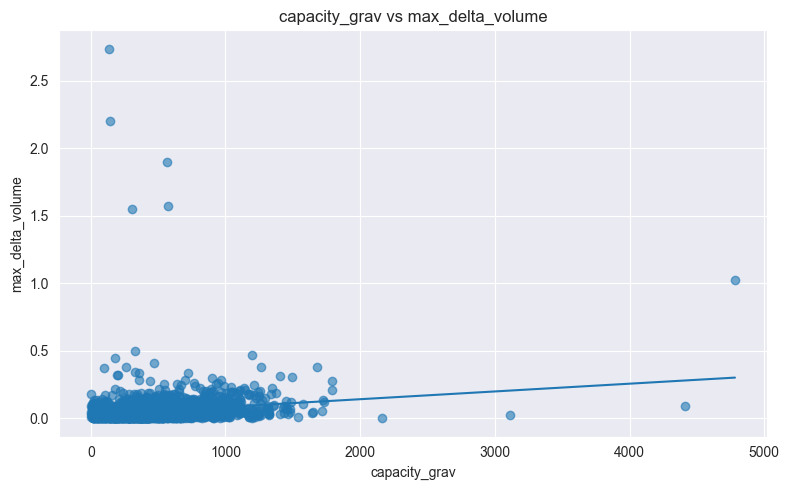

Slope: 5.750662748789399e-05
Intercept: 0.025146476585862654
R²: 0.031903500862383694

         battery_id  capacity_grav  max_delta_volume
23    mp-1111688_Li    2161.122703          0.001452
262    mp-756362_Li    1196.401598          0.002416
742     mp-26387_Li     821.900083          0.000098
382    mp-777681_Li    1215.517917          0.005252
1124   mp-752626_Li     906.409899          0.002767
425   mp-1174049_Li     956.211806          0.003642
1394   mp-755069_Li     976.468808          0.004729
1791   mp-760367_Li     911.796514          0.004596
750     mp-26406_Li    1027.137137          0.006549
1531   mp-756863_Li     904.799767          0.005481
167    mp-752603_Li     748.441774          0.003162
2525   mp-771908_Li    1036.959643          0.008345
162    mp-752600_Li    1538.829743          0.010796
2344   mp-757289_Li     706.460640          0.001922
165    mp-752616_Li     685.018573          0.001232
508     mp-19131_Li     903.661832          0.007151
890     mp-2

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# -------------------------------
# 2. Convert to DataFrame
# -------------------------------
mp_df = pd.DataFrame([{
     "battery_id": m.battery_id,
    "formula_discharge": m.formula_discharge,
    "average_voltage": m.average_voltage,
    "energy_grav": m.energy_grav,
    "capacity_grav": m.energy_grav,
    "stability_charge": m.stability_charge,
    "stability_discharge": m.stability_discharge,
    "max_delta_volume": m.max_delta_volume,
    "fracA_charge": m.fracA_charge,
    "fracA_discharge": m.fracA_discharge
} for m in materials])

# Drop rows with missing values
mp_df = mp_df.dropna()

X_param = 'capacity_grav'
Y_param = 'max_delta_volume'

# -------------------------------
# 3. Define EV-relevant target
# (proxy: density vs stability)
# -------------------------------
X = mp_df[[X_param]]
y = mp_df[[Y_param]]

# -------------------------------
# 4. Linear regression
# -------------------------------
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
slope = model.coef_[0][0]
intercept = model.intercept_[0]



# -------------------------------
# 5. Plot regression
# -------------------------------
x_line = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
x_line_df = pd.DataFrame(x_line, columns=[X_param])
y_line = model.predict(x_line_df)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6)
plt.plot(x_line, y_line)
plt.xlabel(X_param)
plt.ylabel(Y_param)
plt.title(f"{X_param} vs {Y_param}")
plt.tight_layout()
plt.show()

print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r2)
print()
# -------------------------------
# 6. Rank materials for EV relevance
# -------------------------------
mp_df['ev_score'] = (
    mp_df[X_param].rank(pct=True)
    - mp_df[Y_param].rank(pct=True)
)

mp_df = mp_df.sort_values('ev_score', ascending=False)

# -------------------------------
# 7. Output top materials
# -------------------------------
top_materials = mp_df[['battery_id', X_param, Y_param]].head(50)
print(top_materials)


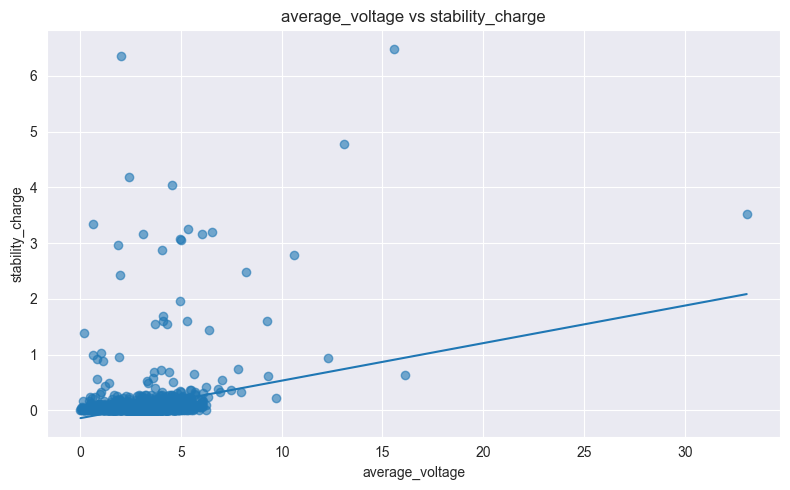

Slope: 0.0673205902819859
Intercept: -0.13851992233139931
R²: 0.07830154083475649

         battery_id  average_voltage  stability_charge
248    mp-755193_Li         6.230379          0.000000
128    mp-561428_Li         5.910340          0.000000
116    mp-541103_Li         5.613607          0.000000
432   mp-1111927_Li         5.506706          0.000000
127    mp-554855_Li         5.337791          0.000000
94      mp-27743_Li         5.318367          0.000000
427   mp-1111150_Li         5.185772          0.000000
37      mp-18536_Li         5.103887          0.000000
23    mp-1111688_Li         5.021094          0.000000
1046   mp-605034_Li         4.950159          0.000000
1038   mp-560878_Li         4.849444          0.000000
199    mp-753171_Li         4.725123          0.000000
1026   mp-556417_Li         4.586988          0.000000
1035   mp-584429_Li         4.571969          0.000000
896     mp-26955_Li         4.835385          0.004463
700     mp-26261_Li         4.701169 

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# -------------------------------
# 2. Convert to DataFrame
# -------------------------------
mp_df = pd.DataFrame([{
     "battery_id": m.battery_id,
    "formula_discharge": m.formula_discharge,
    "average_voltage": m.average_voltage,
    "energy_grav": m.energy_grav,
    "capacity_grav": m.energy_grav,
    "stability_charge": m.stability_charge,
    "stability_discharge": m.stability_discharge,
    "max_delta_volume": m.max_delta_volume,
    "fracA_charge": m.fracA_charge,
    "fracA_discharge": m.fracA_discharge
} for m in materials])

# Drop rows with missing values
mp_df = mp_df.dropna()

X_param = 'average_voltage'
Y_param = 'stability_charge'

# -------------------------------
# 3. Define EV-relevant target
# (proxy: density vs stability)
# -------------------------------
X = mp_df[[X_param]]
y = mp_df[[Y_param]]

# -------------------------------
# 4. Linear regression
# -------------------------------
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
slope = model.coef_[0][0]
intercept = model.intercept_[0]


# -------------------------------
# 5. Plot regression
# -------------------------------
x_line = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
x_line_df = pd.DataFrame(x_line, columns=[X_param])
y_line = model.predict(x_line_df)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6)
plt.plot(x_line, y_line)
plt.xlabel(X_param)
plt.ylabel(Y_param)
plt.title(f"{X_param} vs {Y_param}")
plt.tight_layout()
plt.show()

print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r2)
print()

# -------------------------------
# 6. Rank materials for EV relevance
# -------------------------------
mp_df['ev_score'] = (
    mp_df[X_param].rank(pct=True)
    - mp_df[Y_param].rank(pct=True)
)

mp_df = mp_df.sort_values('ev_score', ascending=False)

# -------------------------------
# 7. Output top materials
# -------------------------------
top_materials = mp_df[['battery_id', X_param, Y_param]].head(50)
print(top_materials)


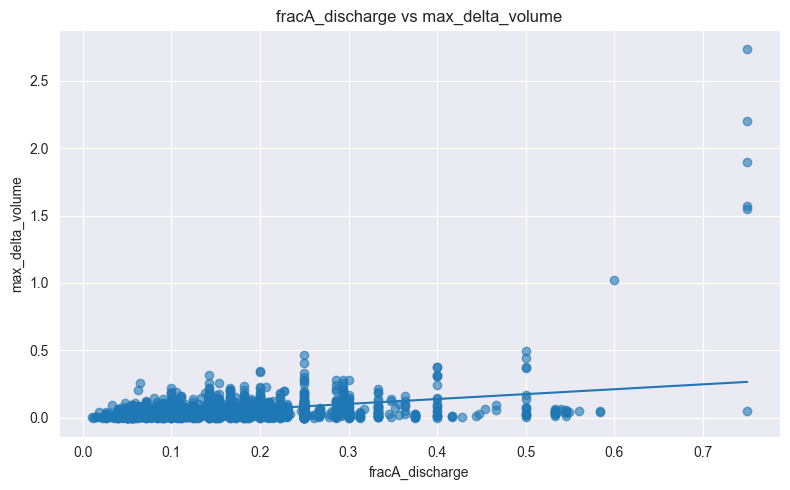

Slope: 0.36325606645176395
Intercept: -0.0063426512552698655
R²: 0.11478484738127326

         battery_id  fracA_discharge  max_delta_volume
1197   mp-753080_Li         0.375000          0.000823
203    mp-753236_Li         0.400000          0.001676
997    mp-504854_Li         0.300000          0.000354
2021   mp-775155_Li         0.416667          0.002572
279    mp-756955_Li         0.312500          0.001655
23    mp-1111688_Li         0.300000          0.001452
167    mp-752603_Li         0.333333          0.003162
2137   mp-850895_Li         0.285714          0.001065
1096   mp-752488_Li         0.375000          0.004549
425   mp-1174049_Li         0.312500          0.003642
253    mp-755266_Li         0.312500          0.004149
1010   mp-554747_Li         0.260870          0.001476
105      mp-3540_Li         0.333333          0.004752
382    mp-777681_Li         0.300000          0.005252
59      mp-19511_Li         0.500000          0.007487
1499   mp-756554_Li         0.2500

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# -------------------------------
# 2. Convert to DataFrame
# -------------------------------
mp_df = pd.DataFrame([{
     "battery_id": m.battery_id,
    "formula_discharge": m.formula_discharge,
    "average_voltage": m.average_voltage,
    "energy_grav": m.energy_grav,
    "capacity_grav": m.energy_grav,
    "stability_charge": m.stability_charge,
    "stability_discharge": m.stability_discharge,
    "max_delta_volume": m.max_delta_volume,
    "fracA_charge": m.fracA_charge,
    "fracA_discharge": m.fracA_discharge
} for m in materials])

# Drop rows with missing values
mp_df = mp_df.dropna()

X_param = 'fracA_discharge'
Y_param = 'max_delta_volume'

# -------------------------------
# 3. Define EV-relevant target
# (proxy: density vs stability)
# -------------------------------
X = mp_df[[X_param]]
y = mp_df[[Y_param]]

# -------------------------------
# 4. Linear regression
# -------------------------------
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
slope = model.coef_[0][0]
intercept = model.intercept_[0]


# -------------------------------
# 5. Plot regression
# -------------------------------
x_line = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
x_line_df = pd.DataFrame(x_line, columns=[X_param])
y_line = model.predict(x_line_df)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6)
plt.plot(x_line, y_line)
plt.xlabel(X_param)
plt.ylabel(Y_param)
plt.title(f"{X_param} vs {Y_param}")
plt.tight_layout()
plt.show()

print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r2)
print()

# -------------------------------
# 6. Rank materials for EV relevance
# -------------------------------
mp_df['ev_score'] = (
    mp_df[X_param].rank(pct=True)
    - mp_df[Y_param].rank(pct=True)
)

mp_df = mp_df.sort_values('ev_score', ascending=False)

# -------------------------------
# 7. Output top materials
# -------------------------------
top_materials = mp_df[['battery_id', X_param, Y_param]].head(50)
print(top_materials)


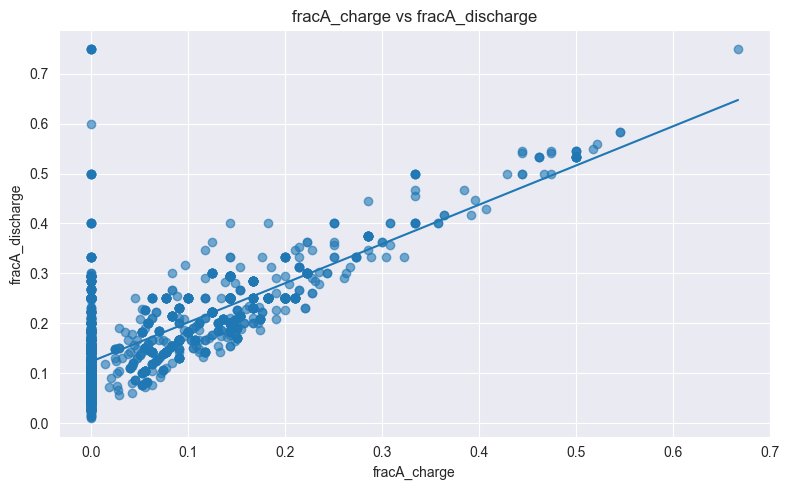

Slope: 0.78630743692497
Intercept: 0.12322274486697221
R²: 0.5197005730584305

         battery_id  fracA_charge  fracA_discharge
452   mp-1222364_Li      0.028571         0.055556
2017   mp-774918_Li      0.041667         0.061224
2433   mp-766028_Li      0.062500         0.076923
2135   mp-850908_Li      0.027397         0.065789
1827   mp-761971_Li      0.055556         0.072727
1828   mp-762032_Li      0.056338         0.082192
737     mp-26368_Li      0.055556         0.081081
724     mp-26329_Li      0.057143         0.083333
633     mp-26049_Li      0.057143         0.083333
721     mp-26319_Li      0.057143         0.083333
2442   mp-766205_Li      0.018868         0.071429
1922   mp-768541_Li      0.052632         0.076923
1917   mp-768515_Li      0.052632         0.076923
1913   mp-768477_Li      0.052632         0.076923
1906   mp-768389_Li      0.052632         0.076923
1903   mp-768320_Li      0.026316         0.075000
2602   mp-778185_Li      0.041667         0.080000
242

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# -------------------------------
# 2. Convert to DataFrame
# -------------------------------
mp_df = pd.DataFrame([{
     "battery_id": m.battery_id,
    "formula_discharge": m.formula_discharge,
    "average_voltage": m.average_voltage,
    "energy_grav": m.energy_grav,
    "capacity_grav": m.energy_grav,
    "stability_charge": m.stability_charge,
    "stability_discharge": m.stability_discharge,
    "max_delta_volume": m.max_delta_volume,
    "fracA_charge": m.fracA_charge,
    "fracA_discharge": m.fracA_discharge
} for m in materials])

# Drop rows with missing values
mp_df = mp_df.dropna()

X_param = 'fracA_charge'
Y_param = 'fracA_discharge'

# -------------------------------
# 3. Define EV-relevant target
# (proxy: density vs stability)
# -------------------------------
X = mp_df[[X_param]]
y = mp_df[[Y_param]]

# -------------------------------
# 4. Linear regression
# -------------------------------
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
slope = model.coef_[0][0]
intercept = model.intercept_[0]


# -------------------------------
# 5. Plot regression
# -------------------------------
x_line = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
x_line_df = pd.DataFrame(x_line, columns=[X_param])
y_line = model.predict(x_line_df)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6)
plt.plot(x_line, y_line)
plt.xlabel(X_param)
plt.ylabel(Y_param)
plt.title(f"{X_param} vs {Y_param}")
plt.tight_layout()
plt.show()

print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r2)
print()

# -------------------------------
# 6. Rank materials for EV relevance
# -------------------------------
mp_df['ev_score'] = (
    mp_df[X_param].rank(pct=True)
    - mp_df[Y_param].rank(pct=True)
)

mp_df = mp_df.sort_values('ev_score', ascending=False)

# -------------------------------
# 7. Output top materials
# -------------------------------
top_materials = mp_df[['battery_id', X_param, Y_param]].head(50)
print(top_materials)


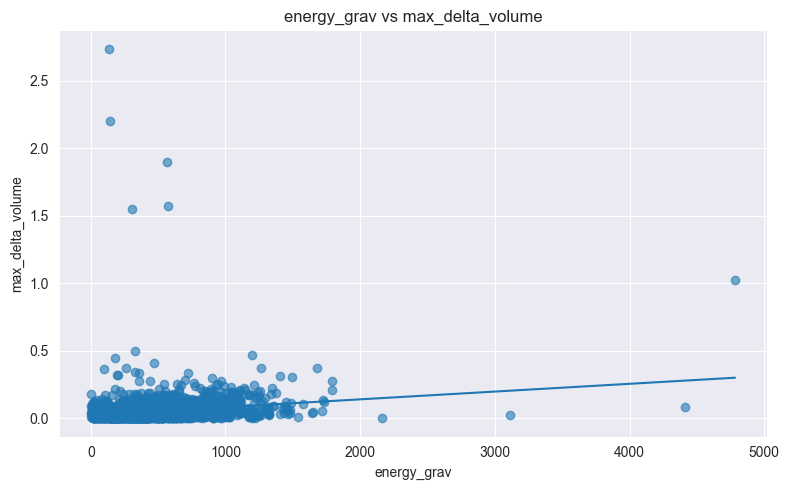

Slope: 5.750662748789399e-05
Intercept: 0.025146476585862654
R²: 0.031903500862383694

         battery_id  energy_grav  max_delta_volume
23    mp-1111688_Li  2161.122703          0.001452
262    mp-756362_Li  1196.401598          0.002416
742     mp-26387_Li   821.900083          0.000098
382    mp-777681_Li  1215.517917          0.005252
1124   mp-752626_Li   906.409899          0.002767
425   mp-1174049_Li   956.211806          0.003642
1394   mp-755069_Li   976.468808          0.004729
1791   mp-760367_Li   911.796514          0.004596
750     mp-26406_Li  1027.137137          0.006549
1531   mp-756863_Li   904.799767          0.005481
167    mp-752603_Li   748.441774          0.003162
2525   mp-771908_Li  1036.959643          0.008345
162    mp-752600_Li  1538.829743          0.010796
2344   mp-757289_Li   706.460640          0.001922
165    mp-752616_Li   685.018573          0.001232
508     mp-19131_Li   903.661832          0.007151
890     mp-26919_Li   733.807951          0.00

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# -------------------------------
# 2. Convert to DataFrame
# -------------------------------
mp_df = pd.DataFrame([{
     "battery_id": m.battery_id,
    "formula_discharge": m.formula_discharge,
    "average_voltage": m.average_voltage,
    "energy_grav": m.energy_grav,
    "capacity_grav": m.energy_grav,
    "stability_charge": m.stability_charge,
    "stability_discharge": m.stability_discharge,
    "max_delta_volume": m.max_delta_volume,
    "fracA_charge": m.fracA_charge,
    "fracA_discharge": m.fracA_discharge
} for m in materials])

# Drop rows with missing values
mp_df = mp_df.dropna()

X_param = 'energy_grav'
Y_param = 'max_delta_volume'

# -------------------------------
# 3. Define EV-relevant target
# (proxy: density vs stability)
# -------------------------------
X = mp_df[[X_param]]
y = mp_df[[Y_param]]

# -------------------------------
# 4. Linear regression
# -------------------------------
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
slope = model.coef_[0][0]
intercept = model.intercept_[0]


# -------------------------------
# 5. Plot regression
# -------------------------------
x_line = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
x_line_df = pd.DataFrame(x_line, columns=[X_param])
y_line = model.predict(x_line_df)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6)
plt.plot(x_line, y_line)
plt.xlabel(X_param)
plt.ylabel(Y_param)
plt.title(f"{X_param} vs {Y_param}")
plt.tight_layout()
plt.show()
print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r2)
print()
# -------------------------------
# 6. Rank materials for EV relevance
# -------------------------------
mp_df['ev_score'] = (
    mp_df[X_param].rank(pct=True)
    - mp_df[Y_param].rank(pct=True)
)

mp_df = mp_df.sort_values('ev_score', ascending=False)

# -------------------------------
# 7. Output top materials
# -------------------------------
top_materials = mp_df[['battery_id', X_param, Y_param]].head(50)
print(top_materials)
